## Load the dataset

In [ ]:
import torch
from transformers import T5ForConditionalGeneration,T5Tokenizer
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [ ]:
# Load the dataset
file_path = "CozmoX Assignment Dataset.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   input_text   96 non-null     object
 1   target_text  96 non-null     object
dtypes: object(2)
memory usage: 1.6+ KB


In [ ]:
df.head(20)

,input_text,target_text
0,I CoLoUr 🎨 the centre of my favourite book.,I color the center of my favorite book.
1,He is travelling ✈️ to the THEATRE.,He is traveling to the theater.
2,I have a flat near the lift.,I have an apartment near the elevator.
3,I have a flat near the lift.,I have an apartment near the elevator.
4,The PROGRAMME 🗓️ will start at 6 O'CLOCK.,The program will start at 6 o'clock.
5,HE has a cheque 💳 for payment.,He has a check for payment.
6,She wears jewellery 💎 on occasions...,She wears jewelry on occasions.
7,THEY are Practising ⚽ for the football MATCH.,They are practicing for the soccer game.
8,He is using a spanner for the repair.,He is using a wrench for the repair.
9,The aeroplane ✈️ landed on time.,The airplane landed on time.


In [ ]:
# Preprocessing

In [ ]:
# Function to clean text (remove extra spaces and normalize case)
def clean_text(text):
    text = text.strip()  # Remove leading/trailing spaces
    text = re.sub(r'[^\x00-\x7F]+', '', text)     # Remove emojis
    text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces with a single space
    return text

# Apply cleaning function
df["input_text"] = df["input_text"].apply(clean_text)
df["target_text"] = df["target_text"].apply(clean_text)

# Display cleaned data sample
df

,input_text,target_text
0,I CoLoUr the centre of my favourite book.,I color the center of my favorite book.
1,He is travelling to the THEATRE.,He is traveling to the theater.
2,I have a flat near the lift.,I have an apartment near the elevator.
3,I have a flat near the lift.,I have an apartment near the elevator.
4,The PROGRAMME will start at 6 O'CLOCK.,The program will start at 6 o'clock.
...,...,...
91,The theatre's performance was breathtaking.,The theater's performance was breathtaking.
92,Her behaviour has been commendable.,Her behavior has been commendable.
93,The cheque was never received.,The check was never received.
94,The aeroplane took off on time.,The airplane took off on time.


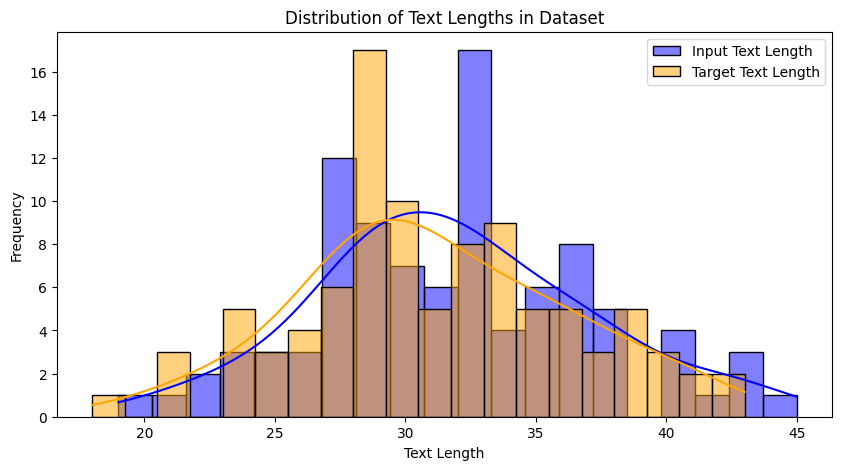

(96,
 2,
        input_length  target_length
 count     96.000000      96.000000
 mean      31.822917      31.052083
 std        5.267567       5.181688
 min       19.000000      18.000000
 25%       28.000000      28.000000
 50%       32.000000      30.000000
 75%       35.000000      35.000000
 max       45.000000      43.000000)

In [ ]:
# Dataset Analysis
num_samples = len(df)
num_columns = df.shape[1]

# Calculate text lengths
df["input_length"] = df["input_text"].apply(len)
df["target_length"] = df["target_text"].apply(len)

# Visualization of text lengths
plt.figure(figsize=(10, 5))
sns.histplot(df["input_length"], bins=20, kde=True, label="Input Text Length", color="blue")
sns.histplot(df["target_length"], bins=20, kde=True, label="Target Text Length", color="orange")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths in Dataset")
plt.legend()
plt.show()

# Display dataset summary
num_samples, num_columns, df.describe()

In [ ]:
# Load T5 tokenizer and model
model = T5ForConditionalGeneration.from_pretrained("EnglishVoice/t5-base-uk-to-us-english").to(device) # Move model to device
tokenizer = T5Tokenizer.from_pretrained("EnglishVoice/t5-base-uk-to-us-english")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define device here
model.to(device)

def format_data(input_text, target_text):
    return f"translate UK to US: {input_text}", target_text

# Prepare dataset
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["input_text"].tolist(), df["target_text"].tolist(), test_size=0.1, random_state=42
)

train_encodings = tokenizer(
    [format_data(text, label)[0] for text, label in zip(train_texts, train_labels)],
    padding=True, truncation=True, return_tensors="pt"
).to(device) # Move train_encodings to device
train_labels_encodings = tokenizer(
    train_labels, padding=True, truncation=True, return_tensors="pt"
).to(device) # Move train_labels_encodings to device

# Training setup
def train_model():
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
    for epoch in range(3):  # Limited epochs for quick training
        optimizer.zero_grad()
        # Move inputs and labels to the same device as the model
        inputs = {k: v.to(device) for k, v in train_encodings.items()} # No need to move again
        labels = train_labels_encodings.input_ids.to(device) # No need to move again

        outputs = model(**inputs, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item()}")

train_model()

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Epoch 1, Loss: 8.581683158874512
Epoch 2, Loss: 8.40404224395752
Epoch 3, Loss: 8.043766975402832


In [ ]:
# Evaluation function
def evaluate_model():
    model.eval()
    val_encodings = tokenizer(
        [format_data(text, label)[0] for text, label in zip(val_texts, val_labels)],
        padding=True, truncation=True, return_tensors="pt"
    ).to(device) # Move val_encodings to the device
    with torch.no_grad():
        outputs = model.generate(**val_encodings)
    predictions = [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]
    bleu_scores = [sentence_bleu([ref.split()], pred.split()) for ref, pred in zip(val_labels, predictions)]
    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    print(f"Average BLEU Score: {avg_bleu:.4f}")

evaluate_model()

Average BLEU Score: 0.5708


In [ ]:
# Inference function
def infer(text):
    model.eval()
    input_text = f"translate UK to US: {text}"
    input_encoding = tokenizer(input_text, return_tensors="pt").to(device) # Move input_encoding to device
    with torch.no_grad():
        output = model.generate(**input_encoding)
    return tokenizer.decode(output[0], skip_special_tokens=True)

# Sample Inference
sample_text = "I love my favourite colour."
print(f"Input: {sample_text}")
print(f"Output: {infer(sample_text)}")

Input: I love my favourite colour.
Output: I love my favorite color.


In [ ]:
# Sample Inference
sample_text = "I have a flat near the lift."
print(f"Input: {sample_text}")
print(f"Output: {infer(sample_text)}")

Input: I have a flat near the lift.
Output: I have an apartment near the elevator.


In [ ]:
# Sample Inference
sample_text = "Do you know where the lift is?"
print(f"Input: {sample_text}")
print(f"Output: {infer(sample_text)}")

Input: Do you know where the lift is?
Output: Do you know where the elevator is?


In [ ]:
# Sample Inference
sample_text = "The aeroplane ✈️ landed on time."
print(f"Input: {sample_text}")
print(f"Output: {infer(sample_text)}")

Input: The aeroplane ✈️ landed on time.
Output: The airplane  landed on time.


In [ ]:
# @title Default title text
Pre-trained for Text Generation: The T5 (Text-to-Text Transfer Transformer) model is well-suited for text-based tasks, including paraphrasing, summarization, and language style adaptation. Since UK and US English differ in spelling, vocabulary, and phrasing, T5’s ability to generate coherent and contextually accurate text makes it an ideal choice.

Handles Context Effectively: Unlike simple rule-based or dictionary-based methods, T5 considers sentence context, ensuring grammatically correct transformations (e.g., "theatre" to "theater" while maintaining sentence structure).


Scalability & Transferability: The model can be further fine-tuned on domain-specific text, making it adaptable for industry applications (e.g., publishing, localization, or AI-driven content moderation).

Enhance Evaluation Metrics: Introduce BLEU, ROUGE, and METEOR scores to quantitatively measure model performance.

Use Data Augmentation: Apply paraphrasing techniques or back-translation to generate more training examples.

Implement a Feedback Loop: Deploy a human-in-the-loop system where users can correct outputs, and the model learns from errors.

Training the model on a limited dataset (96 examples) provides decent performance, but performance could improve with a larger dataset.

Optimize Model Deployment: Convert the model into an API-based system for real-time dialect conversion in chatbots, content management, or writing assistants.

In [ ]:
# Dialect Conversion Model - UK to US English

# Install required dependencies
# !pip install transformers datasets torch

import torch
from transformers import T5ForConditionalGeneration, T5Tokenizer
from sklearn.model_selection import train_test_split
import pandas as pd

# Load dataset
file_path = "CozmoX Assignment Dataset.csv"
df = pd.read_csv(file_path)

# Preprocessing function
def preprocess_text(text):
    text = text.lower().strip()
    return text

df['input_text'] = df['input_text'].apply(preprocess_text)
df['target_text'] = df['target_text'].apply(preprocess_text)

# Split dataset
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['input_text'].tolist(), df['target_text'].tolist(), test_size=0.2, random_state=42)

# Load tokenizer and model
tokenizer = T5Tokenizer.from_pretrained("EnglishVoice/t5-base-uk-to-us-english")
model = T5ForConditionalGeneration.from_pretrained("EnglishVoice/t5-base-uk-to-us-english")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Tokenization
def encode_texts(texts, labels, tokenizer):
    inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    targets = tokenizer(labels, padding=True, truncation=True, return_tensors="pt")
    return inputs, targets

train_inputs, train_targets = encode_texts(train_texts, train_labels, tokenizer)
val_inputs, val_targets = encode_texts(val_texts, val_labels, tokenizer)

# Define training function
def train_model(model, train_inputs, train_targets, val_inputs, val_targets, epochs=3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
    loss_fn = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        input_ids, attention_mask = train_inputs['input_ids'].to(device), train_inputs['attention_mask'].to(device)
        labels = train_targets['input_ids'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item()}")

train_model(model, train_inputs, train_targets, val_inputs, val_targets)

# Save model
model.save_pretrained("uk_to_us_dialect_model")
tokenizer.save_pretrained("uk_to_us_dialect_model")

# Inference function
def convert_text(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)
    outputs = model.generate(**inputs)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Sample inference
sample_text = "I am travelling to the theatre"
print("Converted:", convert_text(sample_text))
